In [1]:
import numpy as np
import pandas as pd

import pyfade

# 1 - Anomaly detection problem

Suppose we have a set of signals, all of them with a sampling period of one hour. These constitute a multidimensional time series. Within these signals, several anomalous behavior occur. We intend to obtain the timestamps where these anomalies appear.

Three methods will be presented here, all based on the calculation of the matrix profile of the signals:

1) Direct calculation of matrix profile on the signal
2) Matrix profile calculation after applying filter
3) Matrix profile on wavelet decomposition

These will be applied in a case study with a signal of increasing complexity.

All matrix profile calculations have these properties:

In [2]:
SUBSEQ_SIZE = 24
QUANTILE = 0
LEFT_ONLY = True
USE_CUDA = True
SKIP_START=SUBSEQ_SIZE*7

MP_PARAMS ={
    'quantile_threshold': QUANTILE,
    'skip_start': SKIP_START,
    'left_only': LEFT_ONLY,
    'use_cuda': USE_CUDA,
}


LEVELS = 4
DIMENSION = 2
WAVELET = 'db2'
TYPE_ANAL = 'denoise'

WAVELET_PARAMS = {
    'wavelet_total_level': LEVELS,
    'wavelet_aggregate_level': DIMENSION,
    'wavelet_analysis_type': TYPE_ANAL,
    'wavelet_type': WAVELET
}


# 2 - Clean signal with anomalies

## 2.1 - Signal creation

The signals whose anomalies are to be calculated are sinusoidal curves with two types of anomalies:

1) Random noise inserted on given timestamps
2) Inclusion of a unitary step

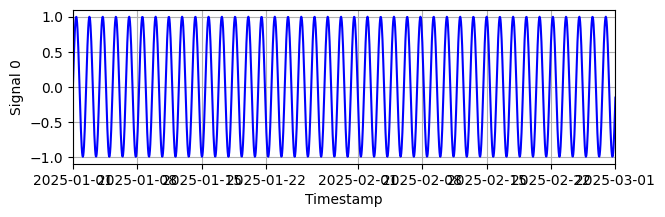

In [3]:
# Signal data
num_signals = 1
start_date = '2025-01-01'
end_date = '2025-03-01'
timestamps = pd.date_range(start_date,end_date,freq='h')
amplitudes = [1, 3, 2, 5, 2]
freq = 1/11 # In 1/h


values = np.empty((timestamps.size,num_signals),dtype=float)
time = (timestamps-timestamps[0]).total_seconds()/3600
for s in range(num_signals):
    values[:,s] = amplitudes[s] * np.sin(2*freq*time)

orig_signals = pd.DataFrame(values,index=timestamps)
orig_signals.columns = [f'Signal {k}' for k in range(num_signals)]
orig_signals.index = pd.to_datetime(orig_signals.index)


builder = pyfade.DataFrameBuilder(orig_signals)
builder.set_extrapolation(pyfade.Extrapolation.CONSTANT)\
            .set_interpolation(pyfade.Interpolation.LINEAR)\
            .build().plot(height=2,width=7);

Now to include the anomalies. This is done in two steps, first we include the random anomalies, then, the step ones.

In [4]:
# Size of the anomalies in hours
size = 24

# Setting up seed so anomalies are always the same when all inputs are the same
rng = np.random.default_rng(2025)

# Anomaly location (# signals with anomaly, start, size)
# rand_anomalies = [(2, '2025-01-10', size, []),
#                   (4, '2025-01-20', size, []),
#                   (1, '2025-01-25', size, [])]

# step_anomalies = [(2, '2025-01-13', size, []),
#                   (1, '2025-01-28', size, [])]


rand_anomalies = [(1, '2025-01-20', size, []),
                  (1, '2025-01-25', size, [])]

step_anomalies = [(1, '2025-01-13', size, [])]

# Inserting random anomalies
anom_signal = orig_signals.copy()
for num_anomalous,start,size,an_list in rand_anomalies:

    if num_anomalous > num_signals:
        num_anomalous = num_signals

    # Getting information, choosing faulty signals and saving this info
    series = rng.choice(num_signals,size=num_anomalous,replace=False)
    an_list.extend(series)

    for s in series:
        col = anom_signal.columns[s]
        anom_signal.loc[pd.date_range(start=start, periods=size, freq='h'),col] += 1 *amplitudes[s] * rng.random(size)

# Inserting step anomalies
for num_anomalous,start,_,an_list in step_anomalies:

    if num_anomalous >= num_signals:
        num_anomalous = num_signals

    # Getting information, choosing faulty signals and saving this info
    series = rng.choice(num_signals,size=num_anomalous,replace=False)
    an_list.extend(series)

    for s in series:
        col = anom_signal.columns[s]
        anom_signal.loc[pd.date_range(start=start, end=anom_signal.index.max(), freq='h'),col] += 1 *amplitudes[s]



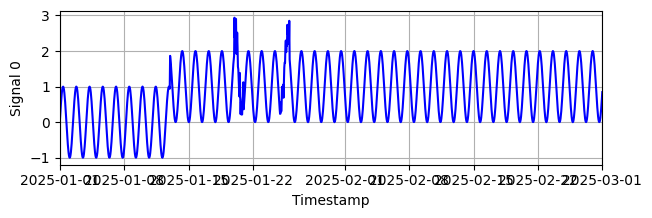

In [5]:
builder = pyfade.DataFrameBuilder(anom_signal)
dataset = builder.set_extrapolation(pyfade.Extrapolation.CONSTANT)\
            .set_interpolation(pyfade.Interpolation.LINEAR)\
            .build()

dataset.plot(height=2,width=7);

In [173]:
# Defining function to plot anomalies
def plot_anomalies(axs,subseq_size):
    for _,start,size,series in rand_anomalies:
        start = pd.Timestamp(start)-pd.Timedelta(hours=subseq_size)
        for s in series:
        # for s in range(1):
            axs[s].axvspan(start,start+pd.Timedelta(hours=size+subseq_size),color=(255/255, 153/255, 153/255),alpha=0.5)

    for _,start,size,series in step_anomalies:
        start = pd.Timestamp(start)-pd.Timedelta(hours=subseq_size)
        for s in series:
        # for s in range(1):
            axs[s].axvspan(start,start+pd.Timedelta(hours=size+subseq_size),color=(153/255, 204/255, 255/255),alpha=0.5)

def plot_n_anomalies(axs,subseq_size):

    try:
        axs = axs.ravel()
    except:
        pass

    for _,start,size,_ in rand_anomalies:
        start = pd.Timestamp(start)-pd.Timedelta(hours=subseq_size)
        for ax in axs:
            ax.axvspan(start,start+pd.Timedelta(hours=size+subseq_size),color=(255/255, 153/255, 153/255),alpha=0.5)

    for _,start,size,_ in step_anomalies:
        start = pd.Timestamp(start)-pd.Timedelta(hours=subseq_size)
        for ax in axs:
            ax.axvspan(start,start+pd.Timedelta(hours=size+subseq_size),color=(153/255, 204/255, 255/255),alpha=0.5)

def plot_anomalies_kdp(axs,subseq_size):

    for k in range(num_signals):
        for num_anomalous,start,size,_ in rand_anomalies:
            start = pd.Timestamp(start)-pd.Timedelta(hours=subseq_size)
            if k < num_anomalous:
                axs[k].axvspan(start,start+pd.Timedelta(hours=size+subseq_size),color='gray',alpha=0.5)

        for num_anomalous,start,size,_ in step_anomalies:
            start = pd.Timestamp(start)-pd.Timedelta(hours=subseq_size)
            if k < num_anomalous:
                axs[k].axvspan(start,start+pd.Timedelta(hours=size+subseq_size),color='gray',alpha=0.5)

def plot_wavelet(axs,subseq_size,signal):

    for _,start,size,series in rand_anomalies:
        start = pd.Timestamp(start)-pd.Timedelta(hours=subseq_size)
        if signal in series:
            for ax in axs:
                ax.axvspan(start,start+pd.Timedelta(hours=size+subseq_size),color='gray',alpha=0.5)

    for _,start,size,series in step_anomalies:
        start = pd.Timestamp(start)-pd.Timedelta(hours=subseq_size)
        if signal in series:
            for ax in axs:
                ax.axvspan(start,start+pd.Timedelta(hours=size+subseq_size),color='gray',alpha=0.5)

def plot_color(window, feature, start=SKIP_START, scale='none', fig=None, ax=None, ylim = [0,1], colormap = 'viridis'):


    from matplotlib import pyplot as plt

    data = window.get_feature(feature).T

    if scale == 'square':
        data = np.square(data)

    x = window.index.to_numpy()
    
    data[:start] = np.nan

    if fig is None and ax is None:
        fig, ax = plt.subplots()
        
    fig, ax = plot_color_from_data(x, data, fig=fig, ax=ax, ylim = ylim, colormap = colormap)

    return fig, ax


def plot_color_from_data(x, data, fig=None, ax=None, ylim = [0,1], colormap = 'viridis'):


    from matplotlib import pyplot as plt
    
    if fig is None and ax is None:
        fig, ax = plt.subplots()
        
    ax.pcolormesh(x,ylim,data[1:].T, cmap=colormap)

    return fig, ax

## 2.2 - Directly on the signal

### 2.2.1 - Matrix Profile

This is a pretty simple signal, we see that just calculating its matrix profile is enough to identify all the anomalies without any issues.

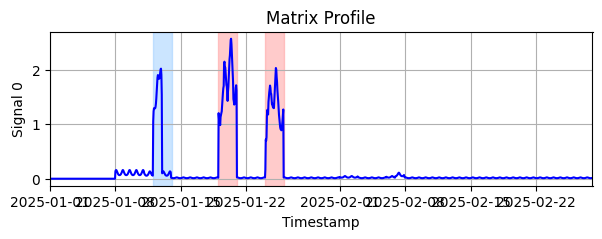

In [7]:
w_builder = pyfade.WindowBuilder(dataset)
w_builder.set_window_size(SUBSEQ_SIZE)
window = w_builder.build()

group_builder = pyfade.FeatureGroupBuilder(pyfade.FeatureGroups.MatrixProfile, window)
group_builder.set_parameters(MP_PARAMS)
group_builder.build()

MP = pd.DataFrame(window.mp.T,index=window.index)

fig, axs = window.plot_feature(pyfade.Features.MatProfileVal, height=2,width=7);
plot_anomalies(axs,SUBSEQ_SIZE)
axs[0].set_title('Matrix Profile');


### 2.2.2 - K-Dimensional Profile

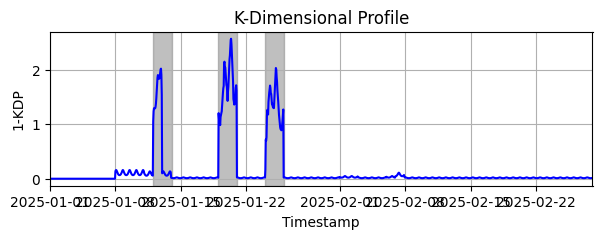

In [8]:
group_builder = pyfade.FeatureGroupBuilder(pyfade.FeatureGroups.KProfile,window).build()

KDP = pd.DataFrame(window.kp.T,index=window.index)

fig, axs = window.plot_feature(pyfade.Features.KProfileVal, height=2,width=7);
plot_anomalies_kdp(axs,SUBSEQ_SIZE)
axs[0].set_title('K-Dimensional Profile');

## 2.3 - Filtered Matrix Profile

Now, a Butterworth pass band filter will be used. The lower and upper frequencies are given as periods.

### 2.3.1 - Butterworth Band: 3rd order 24h - 4h

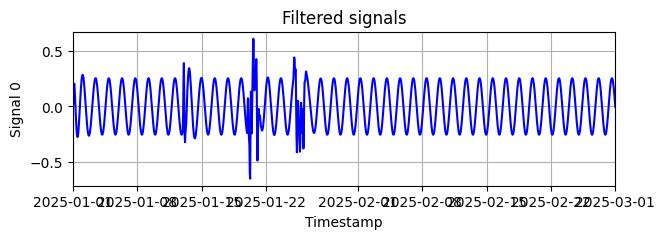

In [9]:
builder = pyfade.DataFrameBuilder(anom_signal)

T_cutoff = np.array([24, 4])
freq_cut = 1/T_cutoff
order = 3

filtered_dataset = builder.set_extrapolation(pyfade.Extrapolation.CONSTANT)\
            .set_interpolation(pyfade.Interpolation.LINEAR)\
            .set_filter(pyfade.FilterType.BUTTER_PASS,order,freq_cut)\
            .build()

fig, axs = filtered_dataset.plot(height=2,width=7);
axs[0].set_title('Filtered signals');

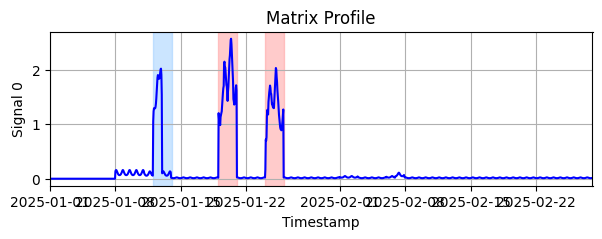

In [10]:
w_builder = pyfade.WindowBuilder(filtered_dataset)
w_builder.set_window_size(SUBSEQ_SIZE)
filtered_window = w_builder.build()

group_builder = pyfade.FeatureGroupBuilder(pyfade.FeatureGroups.MatrixProfile, filtered_window)
group_builder.set_parameters(MP_PARAMS)
group_builder.build()

MP = pd.DataFrame(filtered_window.mp.T,index=filtered_window.index)

fig, axs = window.plot_feature(pyfade.Features.MatProfileVal, height=2,width=7);
plot_anomalies(axs,SUBSEQ_SIZE)
axs[0].set_title('Matrix Profile');

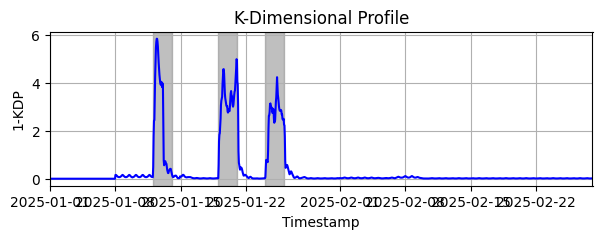

In [11]:
group_builder = pyfade.FeatureGroupBuilder(pyfade.FeatureGroups.KProfile,filtered_window).build()

KDP = pd.DataFrame(filtered_window.kp.T,index=filtered_window.index)

fig, axs = filtered_window.plot_feature(pyfade.Features.KProfileVal, height=2,width=7);
plot_anomalies_kdp(axs,SUBSEQ_SIZE)
axs[0].set_title('K-Dimensional Profile');

Once again, not much difference is seen here, as the signal is well-behaved. Since the period of the original signal is 11 h, note what happens when we exclude it from the band-pass interval:

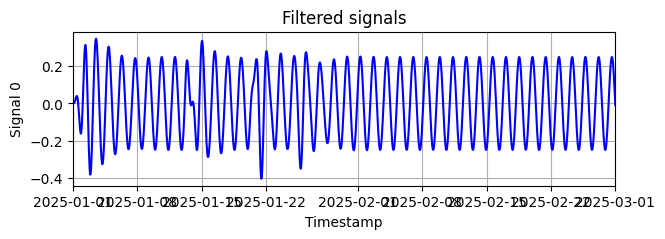

In [12]:
builder = pyfade.DataFrameBuilder(anom_signal)

T_cutoff = np.array([30, 18])
freq_cut = 1/T_cutoff
order = 3

filtered_dataset2 = builder.set_extrapolation(pyfade.Extrapolation.CONSTANT)\
            .set_interpolation(pyfade.Interpolation.LINEAR)\
            .set_filter(pyfade.FilterType.BUTTER_PASS,order,freq_cut)\
            .build()

fig, axs = filtered_dataset2.plot(height=2,width=7);
axs[0].set_title('Filtered signals');

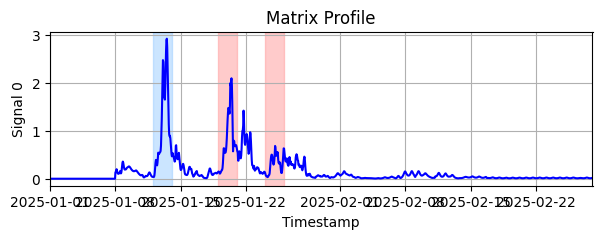

In [13]:
w_builder = pyfade.WindowBuilder(filtered_dataset2)
w_builder.set_window_size(SUBSEQ_SIZE)
filtered_window2 = w_builder.build()

group_builder = pyfade.FeatureGroupBuilder(pyfade.FeatureGroups.MatrixProfile, filtered_window2)
group_builder.set_parameters(MP_PARAMS)
group_builder.build()

MP = pd.DataFrame(filtered_window2.mp.T,index=filtered_window2.index)

fig, axs = filtered_window2.plot_feature(pyfade.Features.MatProfileVal, height=2,width=7);
plot_anomalies(axs,SUBSEQ_SIZE)
axs[0].set_title('Matrix Profile');

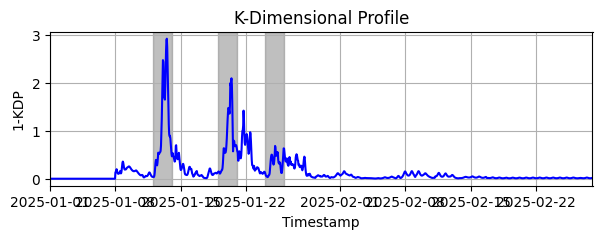

In [14]:
group_builder = pyfade.FeatureGroupBuilder(pyfade.FeatureGroups.KProfile,filtered_window2).build()

KDP = pd.DataFrame(filtered_window2.kp.T,index=filtered_window2.index)

fig, axs = filtered_window2.plot_feature(pyfade.Features.KProfileVal, height=2,width=7);
plot_anomalies_kdp(axs,SUBSEQ_SIZE)
axs[0].set_title('K-Dimensional Profile');

As we removed the periodic regular behavior, the algorithm struggles to find the motifs and discords. Although the matrix profile values do indeed increase where we expect, it also peaks where it shouldn't. Thus, we must make sure we do not filter out regular healthy components from our signal before filtering.

## 2.4 - Wavelet Matrix Profile

In [15]:
WAVELET_PARAMS2 = WAVELET_PARAMS.copy()
WAVELET_PARAMS2['wavelet_total_level']= 2
WAVELET_PARAMS2['wavelet_aggregate_level']= 0
WAVELET_PARAMS2['wavelet_type'] = 'db4'
WAVELET_PARAMS2['wavelet_analysis_type'] = 'kp'

On this last approach, we decompose the signal using a multi-level wavelet decomposition. For instance, let us check the decomposition of the first signal with a level of 3:

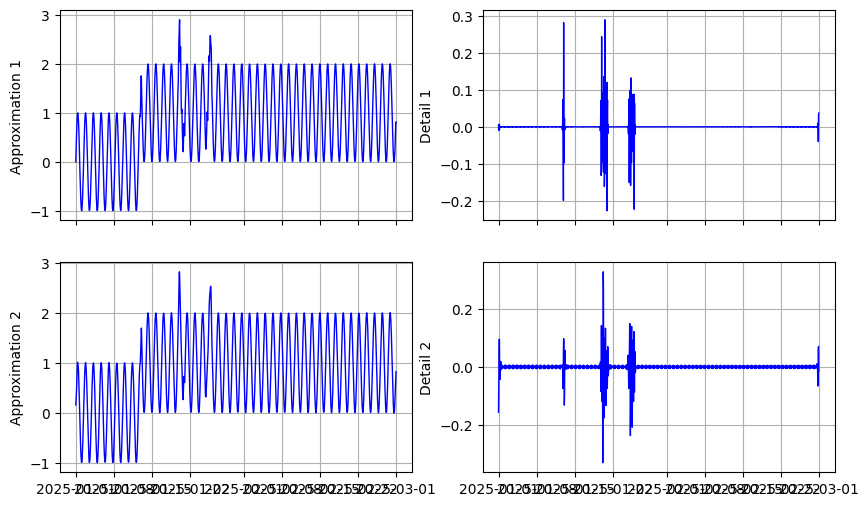

In [16]:
group_builder = pyfade.FeatureGroupBuilder(pyfade.FeatureGroups.WaveletProfile,window,replace=True)
group_builder.set_parameters(MP_PARAMS).set_parameters(WAVELET_PARAMS2)
group_builder.build()

a = window.get_feature('decomposition')[0]

window.get_feature('decomposition')[0].plot();


The curve above shows the original signal and each decomposition level. Each curve shows the reconstructed signal considering only the coefficients from that term. That is, the curves to the left show the reconstruction from the approximation coefficients, while the ones to the right, the reconstruction from the detail coefficients.

For this signal, we can calculate the matrix profile of each successive detail reconstructed curve and on the final approximation one:

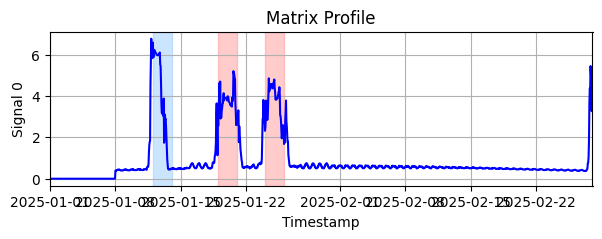

In [17]:
group_builder = pyfade.FeatureGroupBuilder(pyfade.FeatureGroups.WaveletProfile,window,replace=True)
group_builder.set_parameters(MP_PARAMS).set_parameters(WAVELET_PARAMS2)
group_builder.build()


fig,axs = window.plot_feature(pyfade.Features.WaveletMP,height=2,width=7);
plot_anomalies(axs,SUBSEQ_SIZE)
axs[0].set_title('Matrix Profile');

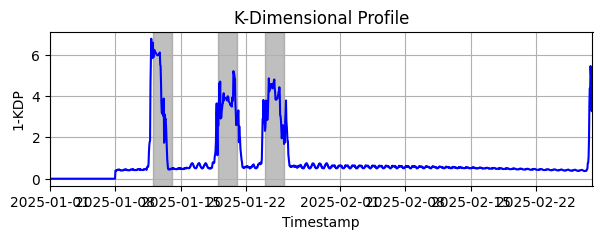

In [18]:
group_builder = pyfade.FeatureGroupBuilder(pyfade.FeatureGroups.WaveletKProfile,window,replace=True).build()

fig,axs = window.plot_feature(pyfade.Features.WaveletKP,height=2,width=7);
plot_anomalies_kdp(axs,SUBSEQ_SIZE)
axs[0].set_title('K-Dimensional Profile');


# 3 - Noisy signal

In [327]:
# Properties
LEVEL_OF_NOISE = 0.8

HEIGHT = 2
WIDTH = 15

## 3.1 - Signal creation

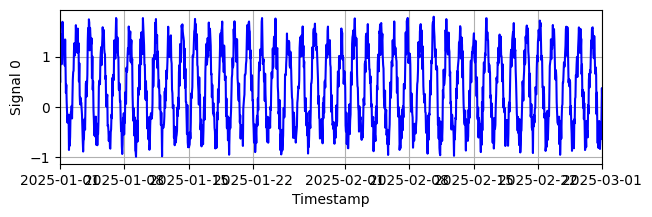

In [328]:
# Signal data
num_signals = 1
start_date = '2025-01-01'
end_date = '2025-03-01'
timestamps = pd.date_range(start_date,end_date,freq='h')
amplitudes = [1, 3, 2, 5, 2]
freq = 1/11 # In 1/h

# Setting up seed so randomness is always the same with same given signal
rng = np.random.default_rng(2025)

values = np.empty((timestamps.size,num_signals),dtype=float)
time = (timestamps-timestamps[0]).total_seconds()/3600
for s in range(num_signals):
    values[:,s] = amplitudes[s] * np.sin(2*freq*time)
    values[:,s] += LEVEL_OF_NOISE *amplitudes[s] * rng.random(time.size)
    


orig_signals = pd.DataFrame(values,index=timestamps)
orig_signals.columns = [f'Signal {k}' for k in range(num_signals)]
orig_signals.index = pd.to_datetime(orig_signals.index)

builder = pyfade.DataFrameBuilder(orig_signals)
builder.set_extrapolation(pyfade.Extrapolation.CONSTANT)\
            .set_interpolation(pyfade.Interpolation.LINEAR)\
            .build().plot(height=2,width=7);


In [329]:
# Size of the anomalies in hours
size = 24

# Setting up seed so anomalies are always the same when all inputs are the same
rng = np.random.default_rng(2025)

# Anomaly location (# signals with anomaly, start, size)
# rand_anomalies = [(2, '2025-01-10', size, []),
#                   (4, '2025-01-20', size, []),
#                   (1, '2025-01-25', size, [])]

# step_anomalies = [(2, '2025-01-13', size, []),
#                   (1, '2025-01-28', size, [])]


rand_anomalies = [(1, '2025-01-20', size, []),
                  (1, '2025-01-25', size, [])]

step_anomalies = [(1, '2025-01-13', size, [])]
# Inserting random anomalies
anom_signal = orig_signals.copy()
for num_anomalous,start,size,an_list in rand_anomalies:

    # Getting information, choosing faulty signals and saving this info
    series = rng.choice(num_signals,size=num_anomalous,replace=False)
    an_list.extend(series)

    for s in series:
        col = anom_signal.columns[s]
        anom_signal.loc[pd.date_range(start=start, periods=size, freq='h'),col] += 1 *amplitudes[s] * rng.random(size)

# Inserting step anomalies
for num_anomalous,start,_,an_list in step_anomalies:

    # Getting information, choosing faulty signals and saving this info
    series = rng.choice(num_signals,size=num_anomalous,replace=False)
    an_list.extend(series)

    for s in series:
        col = anom_signal.columns[s]
        anom_signal.loc[pd.date_range(start=start, end=anom_signal.index.max(), freq='h'),col] += 1 *amplitudes[s]


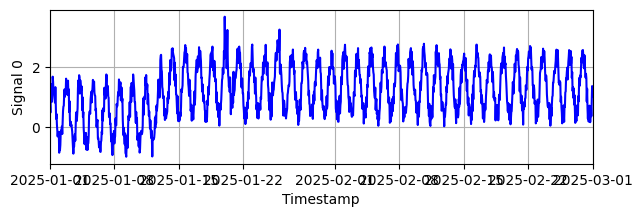

In [330]:
builder = pyfade.DataFrameBuilder(anom_signal)
dataset = builder.set_extrapolation(pyfade.Extrapolation.CONSTANT)\
            .set_interpolation(pyfade.Interpolation.LINEAR)\
            .build()

dataset.plot(height=2,width=7);

## 3.2 - Directly on signal

### 3.2.1 - Matrix Profile

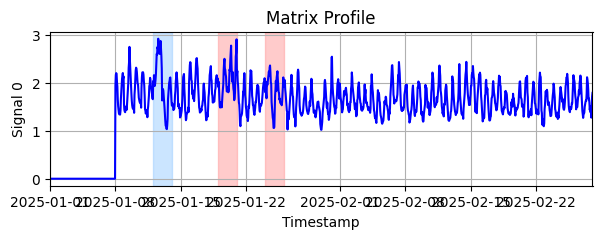

In [331]:
w_builder = pyfade.WindowBuilder(dataset)
w_builder.set_window_size(SUBSEQ_SIZE)
window = w_builder.build()

group_builder = pyfade.FeatureGroupBuilder(pyfade.FeatureGroups.MatrixProfile, window)
group_builder.set_parameters(MP_PARAMS)
group_builder.build()

MP = pd.DataFrame(window.mp.T,index=window.index)

fig, axs = window.plot_feature(pyfade.Features.MatProfileVal, height=2,width=7);
plot_anomalies(axs,SUBSEQ_SIZE)
axs[0].set_title('Matrix Profile');


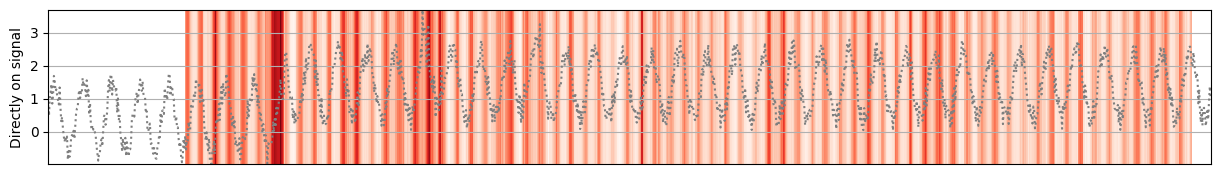

In [332]:
fig, axs = dataset.plot(height=HEIGHT,width=WIDTH,style=':C7');
plot_color(window, pyfade.Features.MatProfileVal,fig=fig,ax=axs[0],ylim=[dataset.data.min(),dataset.data.max()], colormap='Reds',scale='square')
# axs[0].set_title('Matrix Profile');
axs[0].set_ylabel('Directly on signal')
axs[0].set_xlabel('')
axs[0].set_xticks([]);

fig.savefig('MP_raw')

### 3.2.2 - K-Dimensional Profile

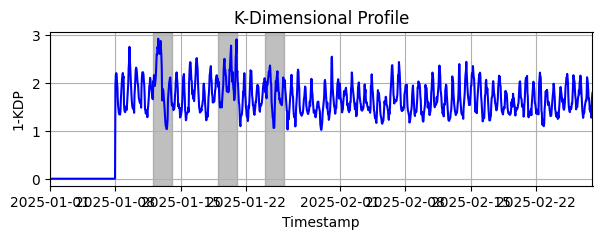

In [333]:
group_builder = pyfade.FeatureGroupBuilder(pyfade.FeatureGroups.KProfile,window).build()

KDP = pd.DataFrame(window.kp.T,index=window.index)

fig, axs = window.plot_feature(pyfade.Features.KProfileVal, height=2,width=7);
plot_anomalies_kdp(axs,SUBSEQ_SIZE)
axs[0].set_title('K-Dimensional Profile');

## 3.3 - Filtered Matrix Profile

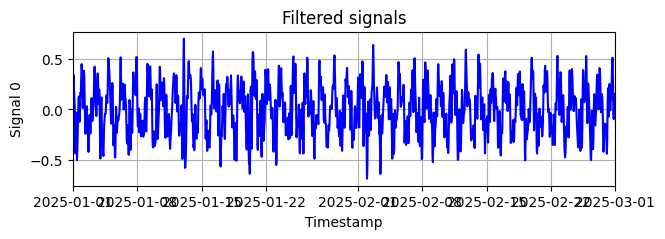

In [334]:
builder = pyfade.DataFrameBuilder(anom_signal)

T_cutoff = np.array([24, 4])
freq_cut = 1/T_cutoff
order = 3

filtered_dataset = builder.set_extrapolation(pyfade.Extrapolation.CONSTANT)\
            .set_interpolation(pyfade.Interpolation.LINEAR)\
            .set_filter(pyfade.FilterType.BUTTER_PASS,order,freq_cut)\
            .build()

fig, axs = filtered_dataset.plot(height=2,width=7);
axs[0].set_title('Filtered signals');

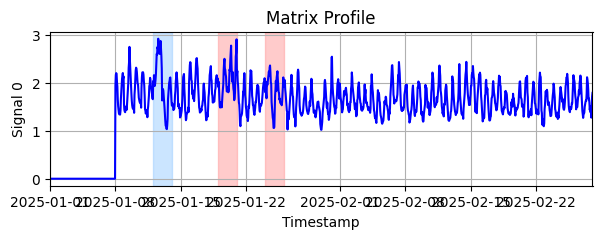

In [335]:
w_builder = pyfade.WindowBuilder(filtered_dataset)
w_builder.set_window_size(SUBSEQ_SIZE)
filtered_window = w_builder.build()

group_builder = pyfade.FeatureGroupBuilder(pyfade.FeatureGroups.MatrixProfile, filtered_window)
group_builder.set_parameters(MP_PARAMS)
group_builder.build()

MP = pd.DataFrame(filtered_window.mp.T,index=filtered_window.index)

fig, axs = window.plot_feature(pyfade.Features.MatProfileVal, height=2,width=7);
plot_anomalies(axs,SUBSEQ_SIZE)
axs[0].set_title('Matrix Profile');

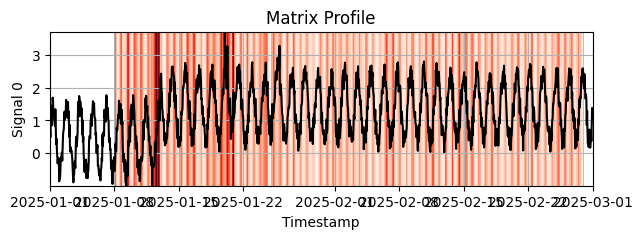

In [336]:
fig, axs = dataset.plot(height=2,width=7,style='k');
plot_anomalies(axs,SUBSEQ_SIZE)
plot_color(window, pyfade.Features.MatProfileVal,fig=fig,ax=axs[0],ylim=[dataset.data.min(),dataset.data.max()], colormap='Reds',scale='square')
axs[0].set_title('Matrix Profile');

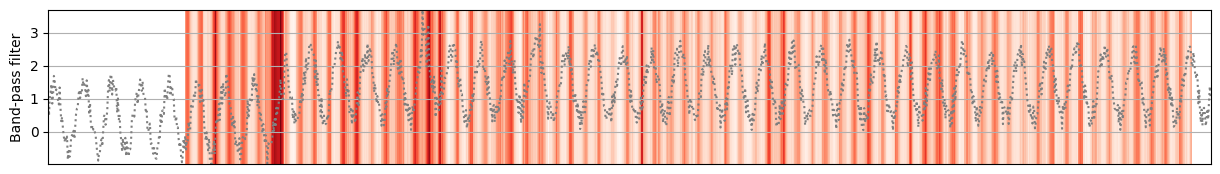

In [337]:
fig, axs = dataset.plot(height=HEIGHT,width=WIDTH,style=':C7');
plot_color(window, pyfade.Features.MatProfileVal,fig=fig,ax=axs[0],ylim=[dataset.data.min(),dataset.data.max()], colormap='Reds',scale='square')
# axs[0].set_title('Matrix Profile');
axs[0].set_ylabel('Band-pass filter')
axs[0].set_xlabel('')
axs[0].set_xticks([]);

fig.savefig('MP_filter')

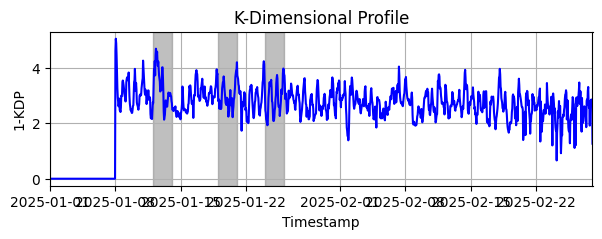

In [338]:
group_builder = pyfade.FeatureGroupBuilder(pyfade.FeatureGroups.KProfile,filtered_window).build()

KDP = pd.DataFrame(filtered_window.kp.T,index=filtered_window.index)

fig, axs = filtered_window.plot_feature(pyfade.Features.KProfileVal, height=2,width=7);
plot_anomalies_kdp(axs,SUBSEQ_SIZE)
axs[0].set_title('K-Dimensional Profile');

## 3.4 - Wavelet Matrix Profile

In [339]:
WAVELET_PARAMS2 = WAVELET_PARAMS.copy()
WAVELET_PARAMS2['wavelet_total_level'] = 5
WAVELET_PARAMS2['wavelet_aggregate_level'] = 1
WAVELET_PARAMS2['wavelet_analysis_type'] = 'denoise'
WAVELET_PARAMS2['wavelet_type'] = 'db4'
WAVELET_PARAMS2['wavelet_denoise_threshold'] = 0.3

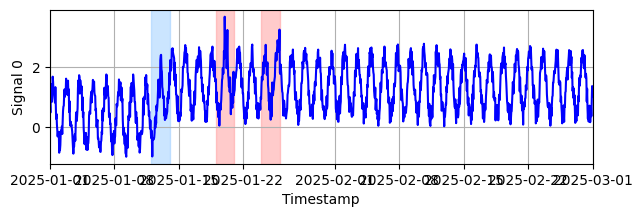

In [340]:
fig, axs = dataset.plot(height=2,width=7);
plot_anomalies(axs,SUBSEQ_SIZE)

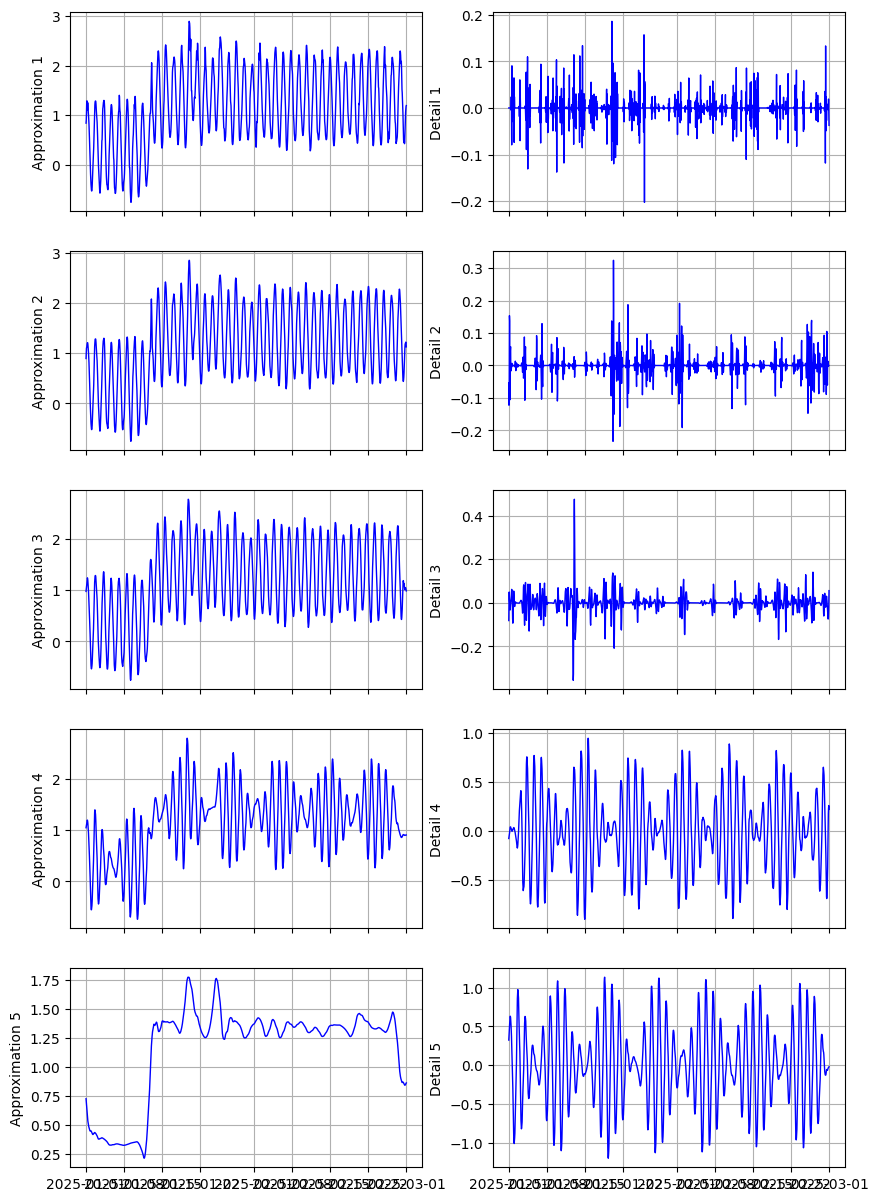

In [341]:
group_builder = pyfade.FeatureGroupBuilder(pyfade.FeatureGroups.WaveletProfile,window,replace=True)
group_builder.set_parameters(MP_PARAMS).set_parameters(WAVELET_PARAMS2)
group_builder.build()

a = window.get_feature('decomposition')[0]

window.get_feature('decomposition')[0].plot();
# plot_n_anomalies(axs,SUBSEQ_SIZE)



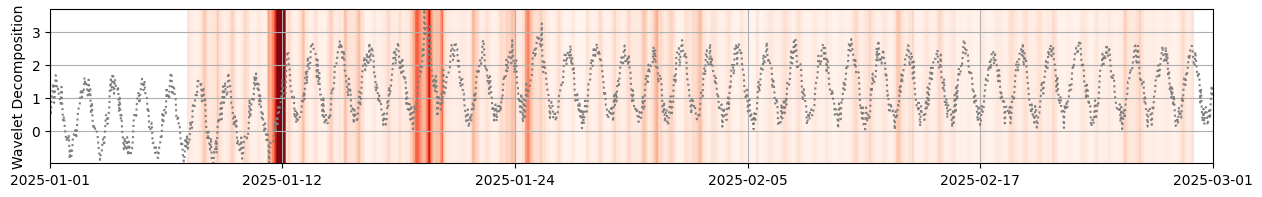

In [342]:
group_builder = pyfade.FeatureGroupBuilder(pyfade.FeatureGroups.WaveletProfile,window,replace=True)
group_builder.set_parameters(MP_PARAMS).set_parameters(WAVELET_PARAMS2)
group_builder.build()

inds = dataset.index.to_numpy()
idx = np.round(np.linspace(0, len(inds) - 1, 6)).astype(int)

fig, axs = dataset.plot(height=HEIGHT,width=WIDTH,style=':C7');
plot_color(window, pyfade.Features.WaveletMP,fig=fig,ax=axs[0],ylim=[dataset.data.min(),dataset.data.max()], colormap='Reds',scale='square')
# axs[0].set_title('Matrix Profile');
axs[0].set_ylabel('Wavelet Decomposition')
axs[0].set_xlabel('')
axs[0].set_xticks(inds[idx]);

fig.savefig('MP_wavelet')



(1417, 1)


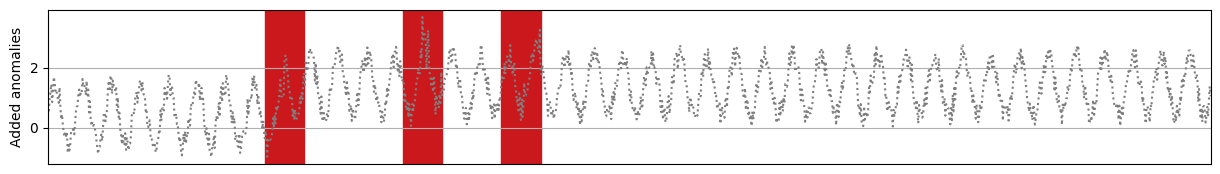

In [343]:
fig, axs = dataset.plot(height=HEIGHT,width=WIDTH,style=':C7');

orig_anom_loc = dataset.data.T*0


reds = (203/255, 24/255, 29/255)



print(orig_anom_loc.shape)

# plot_color_from_data(dataset.index.to_numpy(),orig_anom_loc, fig=fig, ax=axs[0],ylim=[dataset.data.min(),dataset.data.max()], colormap='Reds')

for _,start,size,series in rand_anomalies:
        start = pd.Timestamp(start)-pd.Timedelta(hours=SUBSEQ_SIZE)
        for s in series:
        # for s in range(1):
            axs[s].axvspan(start,start+pd.Timedelta(hours=size+SUBSEQ_SIZE),color=reds)

for _,start,size,series in step_anomalies:
    start = pd.Timestamp(start)-pd.Timedelta(hours=SUBSEQ_SIZE)
    for s in series:
    # for s in range(1):
        axs[s].axvspan(start,start+pd.Timedelta(hours=size+SUBSEQ_SIZE),color=reds)

# axs[0].set_title('Matrix Profile');
axs[0].set_ylabel('Added anomalies')
axs[0].set_xlabel('')
axs[0].set_xticks([]);

fig.savefig('MP_exact')

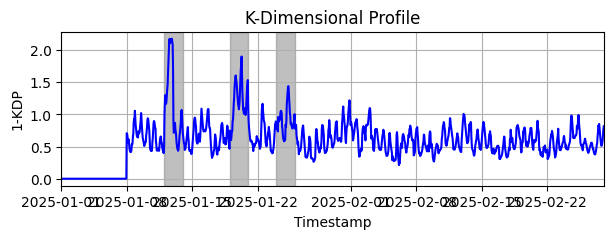

In [344]:
group_builder = pyfade.FeatureGroupBuilder(pyfade.FeatureGroups.WaveletKProfile,window,replace=True).build()

fig,axs = window.plot_feature(pyfade.Features.WaveletKP,height=2,width=7);
plot_anomalies_kdp(axs,SUBSEQ_SIZE)
axs[0].set_title('K-Dimensional Profile');

# 4 - Signal with a lot of frequency components

In [74]:
# Properties
PERIODS_AND_AMPLITUDES = [
    (5, 1),
    (15, 0.5),
    (20, 2),
    (23, 0.7),
    (11, 0.3),
    (1, 10)
]

## 4.1 - Signal creation

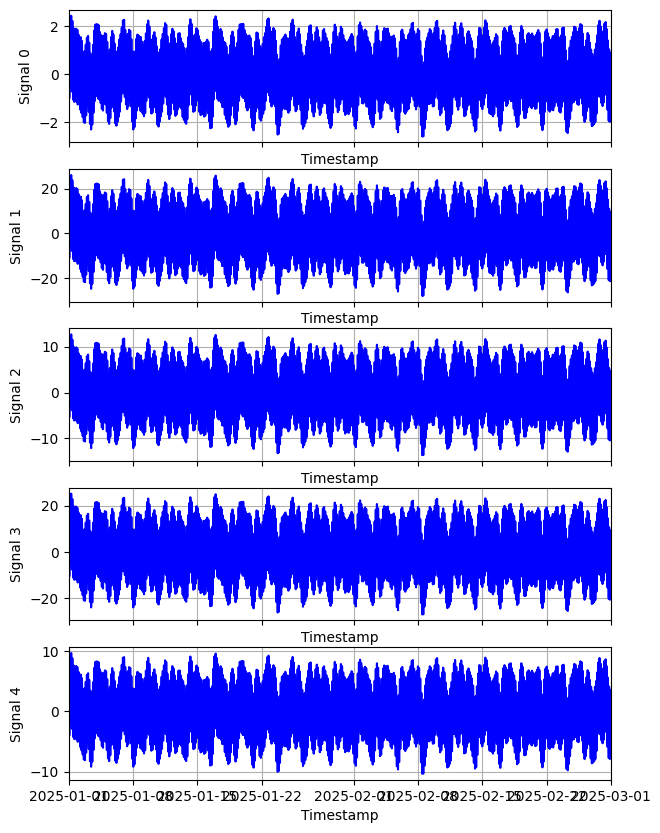

In [75]:
# Signal data
order = np.random.default_rng(2026)
num_signals = 5
start_date = '2025-01-01'
end_date = '2025-03-01'
timestamps = pd.date_range(start_date,end_date,freq='h')
amplitudes = [1* order.random(1), 3* order.random(1), 2* order.random(1), 5* order.random(1), 2* order.random(1)]
freq = 1/11 # In 1/h




values = np.empty((timestamps.size,num_signals),dtype=float)
time = (timestamps-timestamps[0]).total_seconds()/3600
for s in range(num_signals):
    values[:,s] = amplitudes[s] * np.sin(2*freq*time)
    for T, A in PERIODS_AND_AMPLITUDES:
        values[:,s] += A * amplitudes[s] * np.sin(2*(1/T)*time)


orig_signals = pd.DataFrame(values,index=timestamps)
orig_signals.columns = [f'Signal {k}' for k in range(num_signals)]
orig_signals.index = pd.to_datetime(orig_signals.index)

builder = pyfade.DataFrameBuilder(orig_signals)
builder.set_extrapolation(pyfade.Extrapolation.CONSTANT)\
            .set_interpolation(pyfade.Interpolation.LINEAR)\
            .build().plot(height=2,width=7);

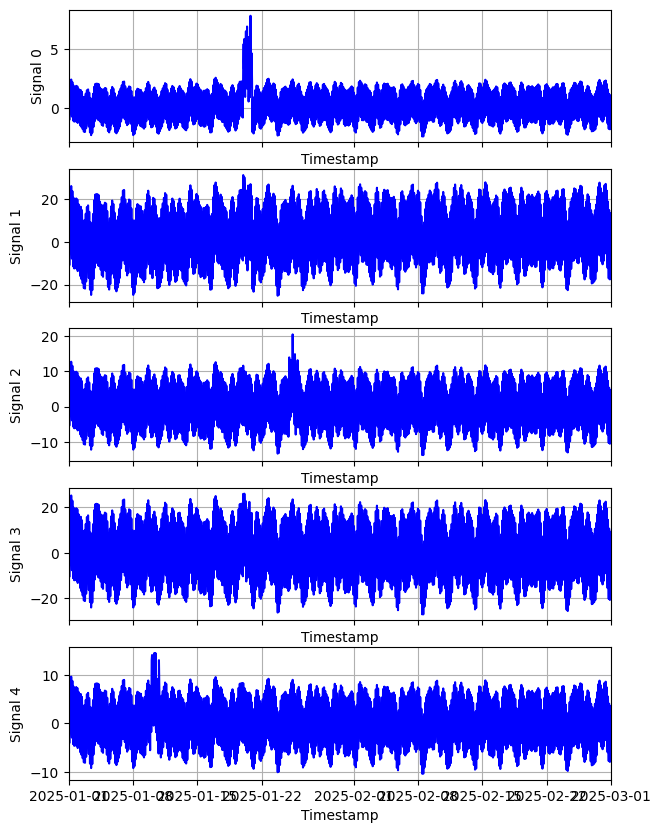

In [76]:
# Size of the anomalies in hours
size = 24

# Setting up seed so anomalies are always the same when all inputs are the same
rng = np.random.default_rng(2025)

# Anomaly location (# signals with anomaly, start, size)
rand_anomalies = [(2, '2025-01-10', size, []),
                  (4, '2025-01-20', size, []),
                  (1, '2025-01-25', size, [])]

step_anomalies = [(2, '2025-01-13', size, []),
                  (1, '2025-01-28', size, [])]

# Inserting random anomalies
anom_signal = orig_signals.copy()

Amp = np.sqrt(np.sum(np.square([a[1] for a in PERIODS_AND_AMPLITUDES])))
for num_anomalous,start,size,an_list in rand_anomalies:

    # Getting information, choosing faulty signals and saving this info
    series = rng.choice(num_signals,size=num_anomalous,replace=False)
    an_list.extend(series)

    for s in series:
        col = anom_signal.columns[s]
        anom_signal.loc[pd.date_range(start=start, periods=size, freq='h'),col] += 1 * (amplitudes[s]+Amp) * rng.random(size)*rng.random(1)

# Inserting step anomalies
for num_anomalous,start,_,an_list in step_anomalies:

    # Getting information, choosing faulty signals and saving this info
    series = rng.choice(num_signals,size=num_anomalous,replace=False)
    an_list.extend(series)

    for s in series:
        col = anom_signal.columns[s]
        anom_signal.loc[pd.date_range(start=start, end=anom_signal.index.max(), freq='h'),col] += 1 *amplitudes[s]

builder = pyfade.DataFrameBuilder(anom_signal)
builder.set_extrapolation(pyfade.Extrapolation.CONSTANT)\
            .set_interpolation(pyfade.Interpolation.LINEAR)\
            .build().plot(height=2,width=7);

## 4.2 - Directly on signal

IndexError: list index out of range

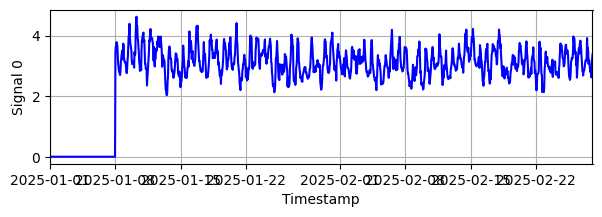

In [77]:
w_builder = pyfade.WindowBuilder(dataset)
w_builder.set_window_size(SUBSEQ_SIZE)
window = w_builder.build()

group_builder = pyfade.FeatureGroupBuilder(pyfade.FeatureGroups.MatrixProfile, window)
group_builder.set_parameters(MP_PARAMS)
group_builder.build()

MP = pd.DataFrame(window.mp.T,index=window.index)

fig, axs = window.plot_feature(pyfade.Features.MatProfileVal, height=2,width=7);
plot_anomalies(axs,SUBSEQ_SIZE)
axs[0].set_title('Matrix Profile');


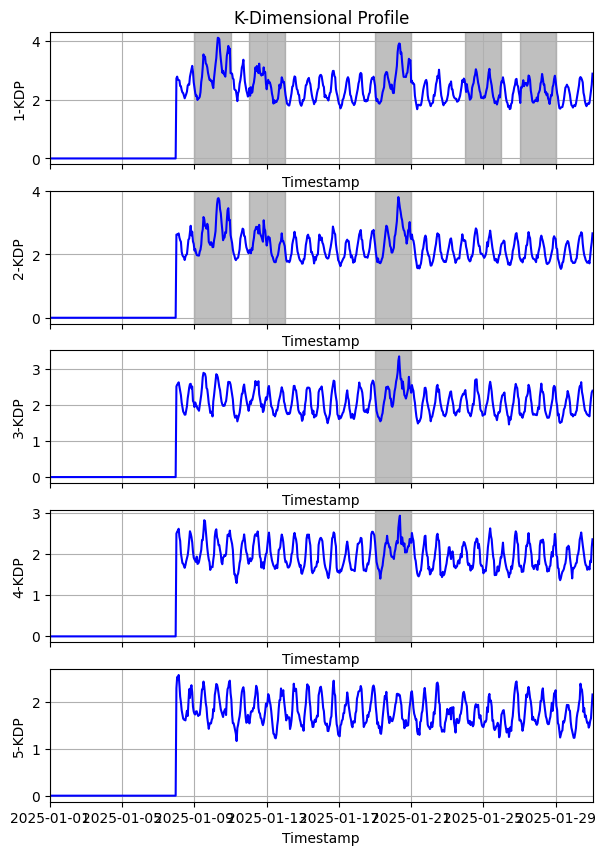

In [ ]:
group_builder = pyfade.FeatureGroupBuilder(pyfade.FeatureGroups.KProfile,window).build()

KDP = pd.DataFrame(window.kp.T,index=window.index)

fig, axs = window.plot_feature(pyfade.Features.KProfileVal, height=2,width=7);
plot_anomalies_kdp(axs,SUBSEQ_SIZE)
axs[0].set_title('K-Dimensional Profile');

## 4.3 - Filtered Matrix Profile

In [ ]:
CUTOFF_PERIODS = [24 , 4]

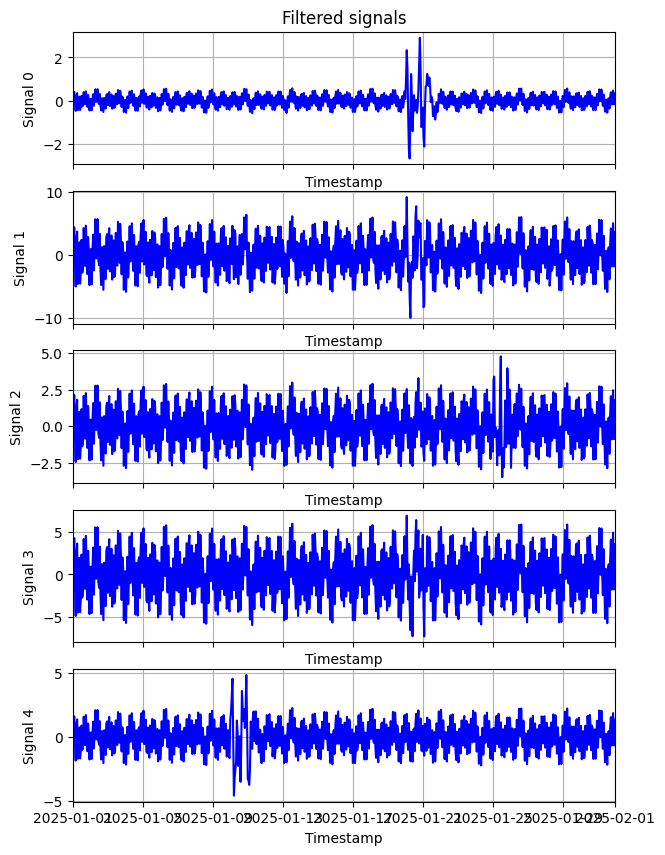

In [ ]:
builder = pyfade.DataFrameBuilder(anom_signal)

T_cutoff = np.array(CUTOFF_PERIODS)
freq_cut = 1/T_cutoff
order = 3

filtered_dataset = builder.set_extrapolation(pyfade.Extrapolation.CONSTANT)\
            .set_interpolation(pyfade.Interpolation.LINEAR)\
            .set_filter(pyfade.FilterType.BUTTER_PASS,order,freq_cut)\
            .build()

fig, axs = filtered_dataset.plot(height=2,width=7);
axs[0].set_title('Filtered signals');

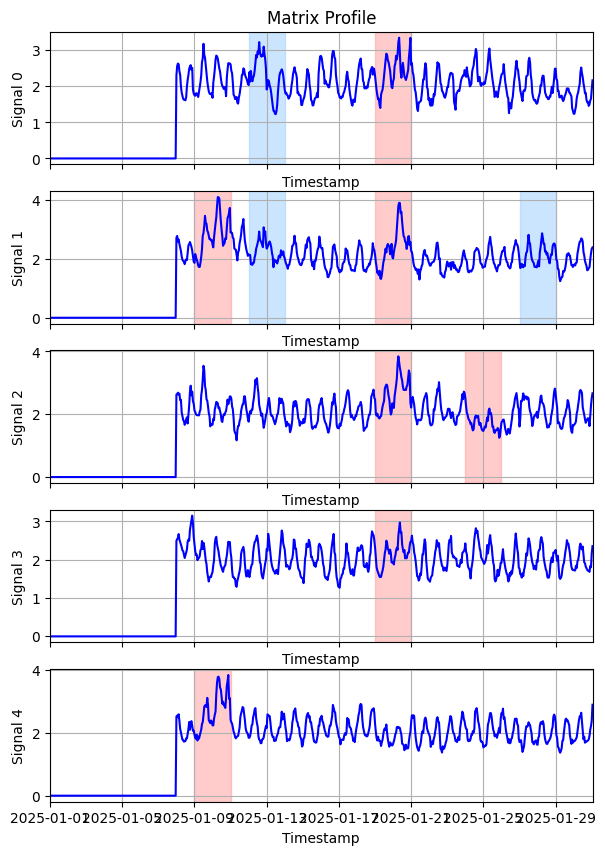

In [ ]:
w_builder = pyfade.WindowBuilder(filtered_dataset)
w_builder.set_window_size(SUBSEQ_SIZE)
filtered_window = w_builder.build()

group_builder = pyfade.FeatureGroupBuilder(pyfade.FeatureGroups.MatrixProfile, filtered_window)
group_builder.set_parameters(MP_PARAMS)
group_builder.build()

MP = pd.DataFrame(filtered_window.mp.T,index=filtered_window.index)

fig, axs = window.plot_feature(pyfade.Features.MatProfileVal, height=2,width=7);
plot_anomalies(axs,SUBSEQ_SIZE)
axs[0].set_title('Matrix Profile');

## 4.4 Wavelet Matrix Profile

In [ ]:
WAVELET_PARAMS2 = WAVELET_PARAMS.copy()
# WAVELET_PARAMS2['wavelet_total_level'] = 3
# WAVELET_PARAMS2['wavelet_aggregate_level'] = 1

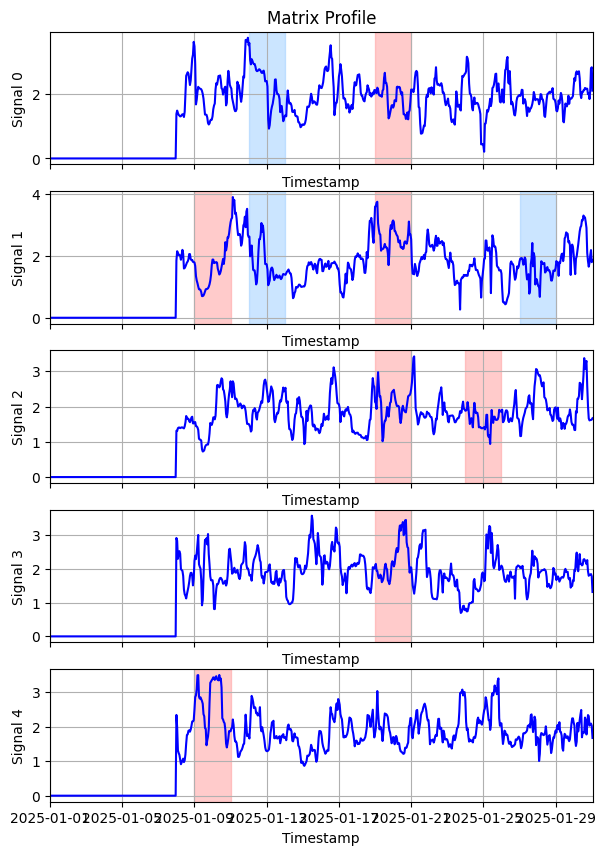

In [ ]:
group_builder = pyfade.FeatureGroupBuilder(pyfade.FeatureGroups.WaveletProfile,window,replace=True)
group_builder.set_parameters(MP_PARAMS).set_parameters(WAVELET_PARAMS2)
group_builder.build()


fig,axs = window.plot_feature(pyfade.Features.WaveletMP,height=2,width=7);
plot_anomalies(axs,SUBSEQ_SIZE)
axs[0].set_title('Matrix Profile');

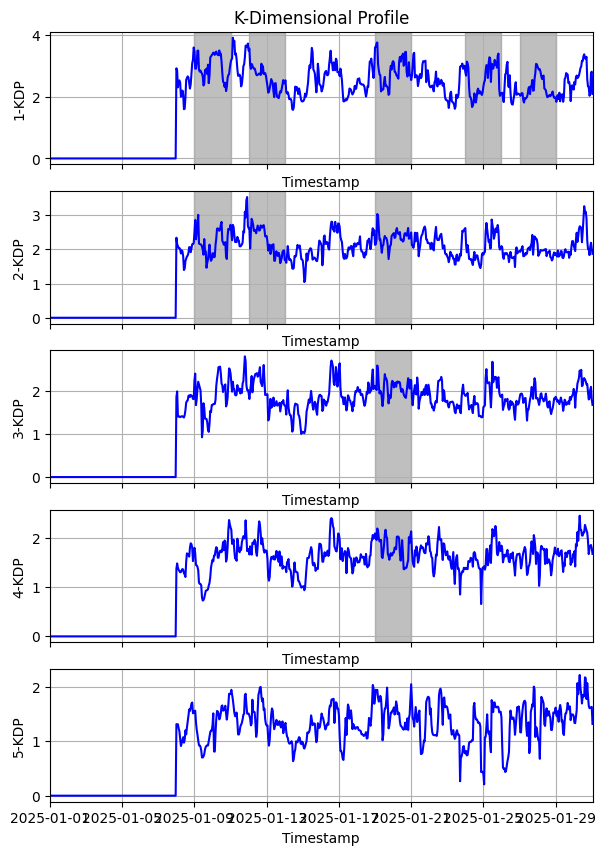

In [ ]:
group_builder = pyfade.FeatureGroupBuilder(pyfade.FeatureGroups.WaveletKProfile,window,replace=True).build()

fig,axs = window.plot_feature(pyfade.Features.WaveletKP,height=2,width=7);
plot_anomalies_kdp(axs,SUBSEQ_SIZE)
axs[0].set_title('K-Dimensional Profile');

# 6 - Signal with frequency components and noise